# Applying SQD to PPP Hamiltonian for Polyacene: Tutorial

This notebook is the **tutorial** part of the SQD exercise set.
It uses the smallest polyacene example, **benzene** (`n_rings = 1`) to inspect the overall workflow lightly.

In this tutorial, we show how to find an approximation to the ground state of a **polyacene Pariser-Parr-Pople (PPP)** Hamiltonian using sampled quantum diagonalization (SQD), starting from uniformly random bitstrings.
For benzene, the model has `6` spatial $\pi$ orbitals, `6` $\pi$ electrons, and therefore a `12`-qubit Jordan-Wigner encoding.
The other orbitals such as $\sigma$-orbitals and cores are assumed to be localized and frozen.
PPP model is one of the most semi-empirical model to describe conjugated systems.

Furthermore, we compare **two orbital bases** for the same Hamiltonian:

1. the original (localized) **site basis** supplied by the PPP model described by $\hat{a}_p^\dagger$,
2. an **RHF-rotated basis** obtained by diagonalizing the mean-field Fock operator, described by $\hat{c}_{\mu}^\dagger$.

The PPP Hamiltonian is

$$
\begin{aligned}
\hat{H}
=&\;
\underbrace{
\sum_{\langle p,q\rangle,\sigma} t_0
\left(
\hat a^\dagger_{p\sigma}\hat a_{q\sigma}
+
\hat a^\dagger_{q\sigma}\hat a_{p\sigma}
\right)
}_{\text{Nearest-neighbor hopping}}
+
\underbrace{
\sum_p U\,\hat n_{p\alpha}\hat n_{p\beta}
}_{\text{On-site Coulomb repulsion}}
\\[0.5em]
&+
\underbrace{
\sum_{p<q} V_{pq}
(\hat n_{p\alpha}+\hat n_{p\beta}-z_p)
(\hat n_{q\alpha}+\hat n_{q\beta}-z_q)
}_{\text{Intersite Coulomb interaction}} .
\end{aligned}
$$

where $\hat n_{p\sigma}=\hat a^\dagger_{p\sigma}\hat a_{p\sigma}$ and the Ohno potential $V_{pq}$ is

$$
V_{pq} = \frac{U}{\sqrt{1 + \left(U r_{pq} / 14.397\right)^2}},
$$

and $r_{pq}$ is the distance between two carbon atoms $p$ and $q$.

Then, we package this into spatial-orbital tensors `hcore` $h_{pr}$ and `eri` $(pr|qs)$,

$$
\hat{H} = \sum_{pq\sigma} h_{pq} \, \hat{a}^\dagger_{p\sigma}\hat{a}_{q\sigma}
+ \frac{1}{2}\sum_{prqs\sigma\tau}(pr|qs)\,
\hat{a}^\dagger_{p\sigma}\hat{a}^\dagger_{q\tau}\hat{a}_{s\tau}\hat{a}_{r\sigma}
+ E_\mathrm{const},
$$

to make it adaptable for SQD and chemistry utilities.

The helper module `polyacene_ppp.py` provides the PPP model in a spin-orbital representation, while `ccsd_wrapper.py` provides an RHF/CCSD driver for user-supplied tensors.


### Load the model

We first load the PPP Hamiltonian in the **site basis**, convert it to the spatial-orbital `hcore` / `eri` representation expected by SQD and PySCF, and then run a lightweight RHF/CCSD calculation.

#### What and Why rotate orbitals?

We begin with the **site basis** $\{|\chi_p\rangle\}$, in which the PPP Hamiltonian is originally defined. Let $ \hat a_{p\sigma}^\dagger $ create an electron with spin $\sigma$ in site orbital $p$.

RHF defines a new orthonormal orbital basis $\{|\phi_\mu\rangle\}$, obtained by diagonalizing the mean-field Fock operator:

$$
F C = C \varepsilon.
$$

The columns of unitary $C$ are the RHF molecular orbitals, and the rotated orbitals are

$$
|\phi_\mu\rangle = \sum_p C_{p\mu} |\chi_p\rangle.
$$

Accordingly, the creation operators transform as

$$
\hat c_{\mu\sigma}^\dagger
=
\sum_p C_{p\mu}\,\hat a_{p\sigma}^\dagger,
$$

where $ \hat c_{\mu\sigma}^\dagger $ creates an electron in RHF orbital $\mu$.

Under this orbital rotation, the one- and two-electron tensors transform from the **site basis** to the **RHF basis** as

$$
h^{\mathrm{RHF}}_{\mu\nu}
=
\sum_{pq}
C_{p\mu}\,
h_{pq}\,
C_{q\nu},
$$

$$
(\mu\nu|\lambda\kappa)^{\mathrm{RHF}}
=
\sum_{pqrs}
C_{p\mu} C_{q\nu} C_{r\lambda} C_{s\kappa}
(pq|rs),
$$

which transforms the expression of the Hamiltonian as

$$
\hat{H} = \sum_{\mu\nu\sigma} h_{\mu\nu}^{\mathrm{RHF}} \hat{c}_{\mu\sigma}^{\dagger}\hat{c}_{\nu\sigma}
+ \frac{1}{2} \sum_{\mu\nu\lambda\kappa\sigma\tau}(\mu\nu|\lambda\kappa)^{\mathrm{RHF}}\,
\hat{c}^\dagger_{\mu\sigma}\hat{c}^\dagger_{\nu\tau}\hat{c}_{\lambda\tau}\hat{c}_{\kappa\sigma}
+ E_\mathrm{const},
$$

A few important points:

- the **exact Hamiltonian** is unchanged by this unitary basis transformation,
- therefore exact diagonalization / FCI energies are basis invariant,
- but **finite sampled subspaces** in SQD depend on the chosen determinant basis,
- so orbital occupancies and SQD convergence can differ between the site basis and the RHF basis.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np

warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from polyacene_ppp import build_polyacene_ppp, spinorb_ppp_to_spatial, plot_coordinate, plot_orbital_spread, plot_site_population
from ccsd_wrapper import run_ccsd_from_hg, transform_integrals_to_mo

Polyacene rings: 1
Spatial orbitals: 6
Spin orbitals / qubits: 12
Electrons (alpha, beta): (3, 3)
Constant intersite Coulomb shift: 91.102943 eV


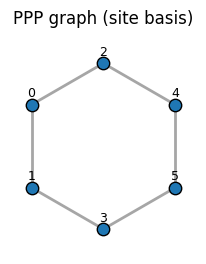

In [2]:
# PPP model parameters for benzene
n_rings = 1
t0 = -2.4          # eV
U = 11.26          # eV
bond_length = 1.4  # Angstrom
kappa = 1.0

ppp_spin = build_polyacene_ppp(
    n_rings=n_rings,
    t0=t0,
    U=U,
    bond_length=bond_length,
    kappa=kappa,
)

hcore_site, eri_site, energy_constant = spinorb_ppp_to_spatial(ppp_spin, U=U)

num_orbitals = hcore_site.shape[0]
num_elec_a = num_orbitals // 2
num_elec_b = num_orbitals // 2
nelec = (num_elec_a, num_elec_b)

print(f"Polyacene rings: {n_rings}")
print(f"Spatial orbitals: {num_orbitals}")
print(f"Spin orbitals / qubits: {2 * num_orbitals}")
print(f"Electrons (alpha, beta): {nelec}")
print(f"Constant intersite Coulomb shift: {energy_constant:.6f} eV")
plot_coordinate(ppp_spin)

### Run RHF and CCSD calculation


Next we run RHF/CCSD. The custom driver internally constructs an RHF reference from the supplied `hcore` and `eri` in the site basis, then solves CCSD on top of that reference. This gives us:

- the RHF energy,
- the CCSD energy,
- the CCSD amplitudes `t1` and `t2`, **(will be required for LUCJ ansatz initialization in the main problem)**
- the RHF orbital coefficient matrix `C`.

We then use `C` to rotate the Hamiltonian into the RHF orbital basis. Since the rotation is unitary, the exact Hamiltonian is unchanged; only its representation changes.


In [3]:
from pyscf.fci import direct_spin1

chemical_accuracy = 0.04336  # eV, equivalent to 1 kcal/mol, often used as a benchmark for "chemical accuracy" in quantum chemistry.

# Get RHF/CCSD data in the original site basis
ccsd_result = run_ccsd_from_hg(
    h=hcore_site,
    g=eri_site,
    nelec=sum(nelec),
    ecore=energy_constant,
    g_format="chemist",
    verbose=4, # adjust here if you don't want to see the detailed CCSD output.
)

hf_energy = ccsd_result["e_hf"]
ccsd_energy = ccsd_result["e_tot"]
t1 = ccsd_result["t1"]
t2 = ccsd_result["t2"]
mo_coeff = np.asarray(ccsd_result["mf"].mo_coeff, dtype=float)  # "mf" means mean-field (RHF) results.

# Rotate the full Hamiltonian into the RHF orbital basis
hcore_rhf, eri_rhf = transform_integrals_to_mo(hcore_site, eri_site, mo_coeff)

# Inspect how well the RHF orbital basis diagonalizes the mean-field Fock operator
fock_site = np.asarray(ccsd_result["mf"].get_fock(), dtype=float)
fock_rhf = mo_coeff.T @ fock_site @ mo_coeff
fock_offdiag_norm = np.linalg.norm(fock_rhf - np.diag(np.diag(fock_rhf)))

# Compute the FCI energy in the original site basis for reference
fci_energy, _ = direct_spin1.kernel(
    hcore_site,
    eri_site,
    num_orbitals,
    nelec,
    ecore=energy_constant,
)


print("\n=== RHF/CCSD Results ===")
print(f"RHF energy                     : {hf_energy:.6f} eV")
print(f"CCSD energy                    : {ccsd_energy:.6f} eV")
print(f"FCI energy                     : {fci_energy:.6f} eV")
print(f"Chemical accuracy threshold    : {chemical_accuracy:.6f} eV")
print(f"t1 shape                       : {t1.shape}")
print(f"t2 shape                       : {t2.shape}")
print(f"MO coefficient matrix shape    : {mo_coeff.shape}")
print(f"||offdiag(C^T F C)||_F         : {fock_offdiag_norm:.3e}")
print(f"||h_site||_F                   : {np.linalg.norm(hcore_site):.6f}")
print(f"||h_rhf||_F                    : {np.linalg.norm(hcore_rhf):.6f}")  # should be the same as h_site due to unitary transformation




******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = 1e
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 200
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmp5lxa_456
max_memory 4000 MB (current use 191 MB)
Set gradient conv threshold to 3.16228e-05
Initial guess from hcore.
  HOMO = -32.7676475634921  LUMO = -27.9676475634924
init E= -13.2140161208222
  HOMO = -0.0806551256347172  LUMO = 11.3406551256347
cycle= 1 E= -13.2140161208222  delta_E= -2.84e-14  |g|= 3.48e-13  |ddm|= 9.47e-14
  HOMO = -0.0806551256346875  LUMO = 11.3406551256347
Extra cycle  E= -13.2140161208222  delta_E= 2.84e-14  |g|= 1.26e-13  |ddm|= 3.33e-14
converged SCF energy = -13.2140161208222


Overwritten attributes  get_hcore get_ovlp  of <class 'pyscf.scf.hf.RHF'>


E(CCSD) = -13.99852639676286  E_corr = -0.784510275940691

=== RHF/CCSD Results ===
RHF energy                     : -13.214016 eV
CCSD energy                    : -13.998526 eV
FCI energy                     : -14.012501 eV
Chemical accuracy threshold    : 0.043360 eV
t1 shape                       : (3, 3)
t2 shape                       : (3, 3, 3, 3)
MO coefficient matrix shape    : (6, 6)
||offdiag(C^T F C)||_F         : 9.012e-14
||h_site||_F                   : 74.848408
||h_rhf||_F                    : 74.848408


The RHF coefficient matrix `mo_coeff = C` rotates the **site basis** into the **RHF orbital basis**. 
For a given RHF orbital $\mu$, the quantity $|C_{p\mu}|^2$ gives the weight of that orbital on site $p$. 
Here, we show how the lowest ($\mu = 0$), HOMO ($\mu = 2$), LUMO ($\mu = 3$), and highest ($\mu = 5$) orbitals are composed of local orbitals.

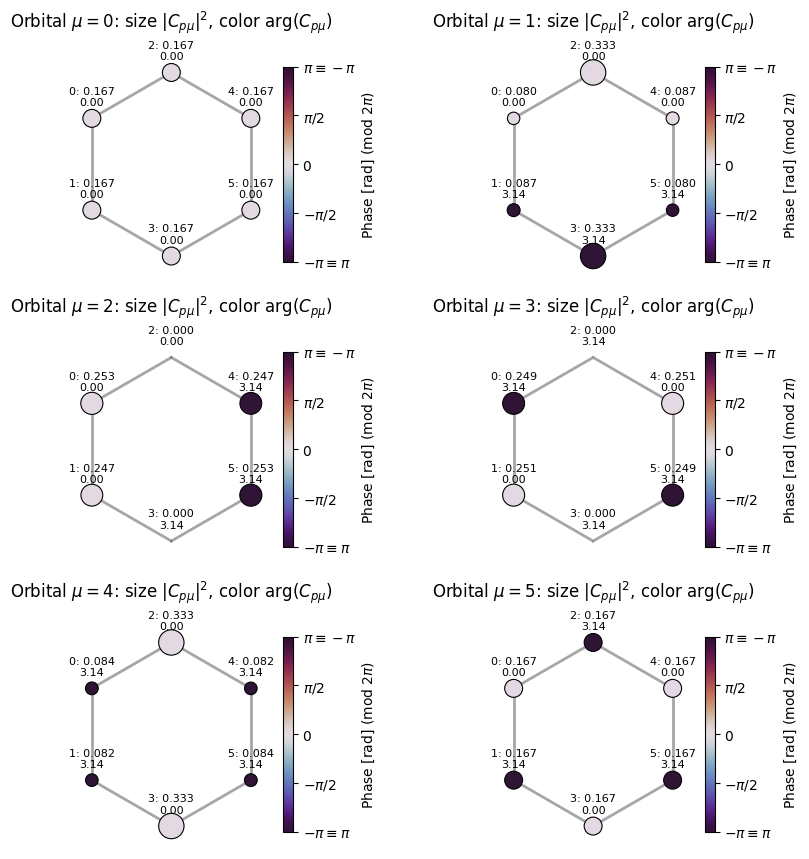

array([[<Axes: title={'center': 'Orbital $\\mu = 0$: size $|C_{p\\mu}|^2$, color $\\arg(C_{p\\mu})$'}>,
        <Axes: title={'center': 'Orbital $\\mu = 1$: size $|C_{p\\mu}|^2$, color $\\arg(C_{p\\mu})$'}>],
       [<Axes: title={'center': 'Orbital $\\mu = 2$: size $|C_{p\\mu}|^2$, color $\\arg(C_{p\\mu})$'}>,
        <Axes: title={'center': 'Orbital $\\mu = 3$: size $|C_{p\\mu}|^2$, color $\\arg(C_{p\\mu})$'}>],
       [<Axes: title={'center': 'Orbital $\\mu = 4$: size $|C_{p\\mu}|^2$, color $\\arg(C_{p\\mu})$'}>,
        <Axes: title={'center': 'Orbital $\\mu = 5$: size $|C_{p\\mu}|^2$, color $\\arg(C_{p\\mu})$'}>]],
      dtype=object)

In [4]:
plot_orbital_spread(ppp_spin, mo_coeff, orbital_indices=[0, 1, 2, 3, 4, 5])

For this small benzene example, we can also run FCI to get an exact many-body benchmark.

### Run virtual SQD based on randomly generated bitstrings

Sampled quantum diagonalization (SQD) proceeds as follows:

1. Obtain samples from an ansatz. (In this tutorial, we instead use uniformly random samples; later, you will implement the ansatz-based version.)
2. Run the configuration recovery loop until the energy or orbital occupancies converge.

Each configuration recovery loop consists of the following steps:

1. Construct a refined bitstring matrix and probability array based on the average orbital occupancies. (skipped in the first iteration)
2. Collect batches of subsamples for diagonalization.
3. Diagonalize each subsample batch to obtain an approximation to the ground state.

The configuration recovery removes any non-physical samples (samples with incorrect Hamming weight) before running the eigenstate solver on a subspace batch.
Afterward, the average orbital occupation is calculated across all batches to flip individual bits probabilistically based on this average. 

In real SQD, the bitstring samples are obtained from measurements of a quantum circuit, for example using the **local unitary cluster Jastrow (LUCJ) ansatz**. The implementation and initialization of the LUCJ ansatz will be presented in the problem section.

Here, instead of quantum samples, we run **virtual SQD** using uniformly random bitstrings. Through virtual SQD, we compare the results in two bases:

1. the **original site basis**, and
2. the **RHF-rotated basis**.

In [5]:

import numpy as np
from qiskit_addon_sqd.counts import generate_bit_array_uniform

seed = 24
bit_array_site = generate_bit_array_uniform(
    200, num_orbitals * 2, rand_seed=np.random.default_rng(seed)
)

bit_array_rhf = generate_bit_array_uniform(
    200, num_orbitals * 2, rand_seed=np.random.default_rng(seed)
)



In [6]:
from functools import partial

from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch, solve_sci

# SQD options
energy_tol = 1e-5
occupancies_tol = 1e-5
max_iterations = 5

# Eigenstate solver options
num_batches = 1
samples_per_batch = 20
symmetrize_spin = True
carryover_threshold = 1e-4
max_cycle = 200

sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=max_cycle)

def run_sqd_case(label, hcore, eri, bit_array, seed):
    history = []

    def callback(results: list[SCIResult]):
        history.append(results)
        iteration = len(history)
        print(f"{label} | iteration {iteration}")
        for i, result in enumerate(results):
            print(f"    subsample {i}")
            print(f"        Energy: {result.energy + energy_constant:.6f} eV")
            print(
                f"        Subspace dimension: "
                f"{np.prod(result.sci_state.amplitudes.shape)}"
            )

    result = diagonalize_fermionic_hamiltonian(
        hcore,
        eri,
        bit_array,
        samples_per_batch=samples_per_batch,
        norb=num_orbitals,
        nelec=nelec,
        num_batches=num_batches,
        energy_tol=energy_tol,
        occupancies_tol=occupancies_tol,
        max_iterations=max_iterations,
        sci_solver=sci_solver,
        symmetrize_spin=symmetrize_spin,
        carryover_threshold=carryover_threshold,
        callback=callback,
        seed=np.random.default_rng(seed),
    )

    min_energies = [
        min(result_batch, key=lambda res: res.energy).energy + energy_constant
        for result_batch in history
    ]
    occupancy = np.sum(result.orbital_occupancies, axis=0)

    return {
        "label": label,
        "history": history,
        "result": result,
        "min_energies": min_energies,
        "occupancy": occupancy,
    }

site_case = run_sqd_case(
    label="site basis",
    hcore=hcore_site,
    eri=eri_site,
    bit_array=bit_array_site,
    seed=24,
)

rhf_case = run_sqd_case(
    label="RHF basis",
    hcore=hcore_rhf,
    eri=eri_rhf,
    bit_array=bit_array_rhf,
    seed=24,
)


site basis | iteration 1
    subsample 0
        Energy: -8.217303 eV
        Subspace dimension: 256
site basis | iteration 2
    subsample 0
        Energy: -13.822062 eV
        Subspace dimension: 361
site basis | iteration 3
    subsample 0
        Energy: -13.822062 eV
        Subspace dimension: 361
RHF basis | iteration 1
    subsample 0
        Energy: -13.640792 eV
        Subspace dimension: 256
RHF basis | iteration 2
    subsample 0
        Energy: -13.855518 eV
        Subspace dimension: 361
RHF basis | iteration 3
    subsample 0
        Energy: -14.012501 eV
        Subspace dimension: 400
RHF basis | iteration 4
    subsample 0
        Energy: -14.012501 eV
        Subspace dimension: 400


### Visualize the results

Now we compare the two SQD trajectories.
Since both runs use the same PPP Hamiltonian written in two bases, any difference comes from the basis dependence of the sampled SQD subspaces, not from a change in the underlying physical model.

When the RHF rotation helps, the usual reason is that the mean-field orbitals produce a determinant basis closer to the correlated ground state, so the selected-CI subspaces found from finite samples can become more effective.


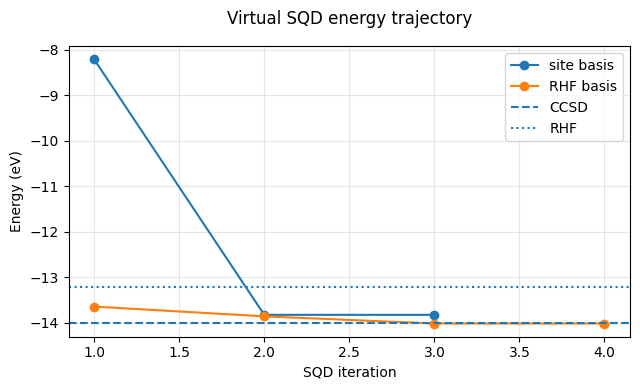

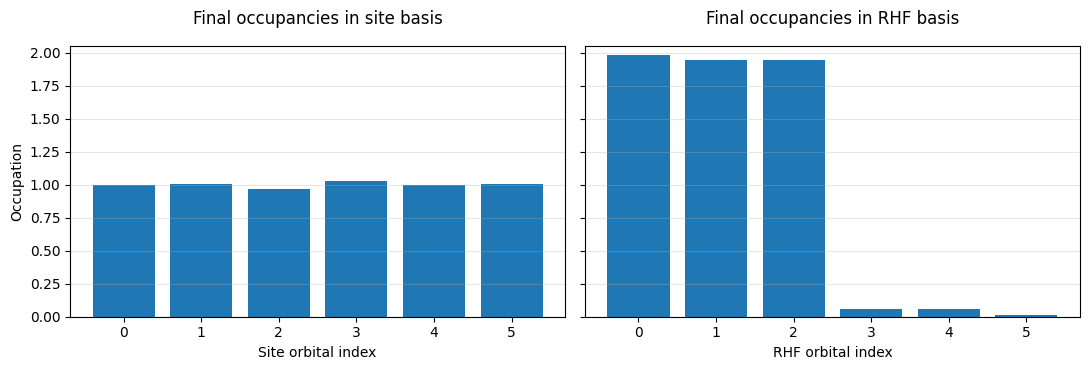

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.0))
iters_site = np.arange(1, len(site_case["min_energies"]) + 1)
iters_rhf = np.arange(1, len(rhf_case["min_energies"]) + 1)

ax.plot(iters_site, site_case["min_energies"], marker="o", label="site basis")
ax.plot(iters_rhf, rhf_case["min_energies"], marker="o", label="RHF basis")
ax.axhline(ccsd_energy, linestyle="--", linewidth=1.5, label="CCSD")
ax.axhline(hf_energy, linestyle=":", linewidth=1.5, label="RHF")
ax.set_xlabel("SQD iteration")
ax.set_ylabel("Energy (eV)")
ax.set_title("Virtual SQD energy trajectory", pad=16)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

axes[0].bar(np.arange(num_orbitals), site_case["occupancy"])
axes[0].set_title("Final occupancies in site basis", pad=16)
axes[0].set_xlabel("Site orbital index")
axes[0].set_ylabel("Occupation")
axes[0].set_ylim(0, 2.05)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(np.arange(num_orbitals), rhf_case["occupancy"])
axes[1].set_title("Final occupancies in RHF basis", pad=16)
axes[1].set_xlabel("RHF orbital index")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()




### Tutorial Summary

- Observed SQD workflow without implementing the ansatz.
- The **site basis** and **RHF basis** describe the same PPP Hamiltonian.
- The RHF orbital matrix diagonalizes the mean-field Fock operator, not necessarily the full interacting Hamiltonian.
- Exact many-body energies are basis invariant, but practical **SQD performance can depend on the basis** because the sampled determinant subspaces depend on that choice.


### References
- Robledo-Moreno, Javier, Mario Motta, Holger Haas, Ali Javadi-Abhari, Petar Jurcevic, William Kirby, Simon Martiel, Kunal Sharma, Sandeep Sharma, Tomonori Shirakawa, Iskandar Sitdikov, Rong-Yang Sun, Kevin J. Sung, Maika Takita, Minh C. Tran, Seiji Yunoki, and Antonio Mezzacapo. “Chemistry Beyond the Scale of Exact Diagonalization on a Quantum-Centric Supercomputer.” *Science Advances* **11**, no. 25 (2025): eadu9991. https://www.science.org/doi/10.1126/sciadv.adu9991

- Improving energy estimation of a chemistry Hamiltonian with SQD. Qiskit addon: sample-based quantum diagonalization (SQD) 0.12.0 documentation. https://qiskit.github.io/qiskit-addon-sqd/tutorials/01_chemistry_hamiltonian.html

- Getting started with Sample-based quantum diagonalization (SQD) https://quantum.cloud.ibm.com/docs/en/guides/qiskit-addons-sqd-get-started

- Fabian, Marcel David, Nina Glaser, and Gemma C. Solomon. *The PPP model - a minimal viable parametrisation of conjugated chemistry for modern computing applications*. arXiv:2510.04632, 2025. https://arxiv.org/abs/2510.04632

- Raghu, C., Y. Anusooya Pati, and S. Ramasesha. “Structural and electronic instabilities in polyacenes: Density-matrix renormalization group study of a long-range interacting model.” *Physical Review B* **65** (2002): 155204. https://doi.org/10.1103/PhysRevB.65.155204